In [84]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

RANDOM_SEED = 42
N_SAMPLES = 1000
IMG_SIZE = (128, 128)

TARGET_COLS = ["race", "gender", "age"]

In [85]:
download_path = kagglehub.dataset_download("mehmoodsheikh/fairface-dataset")
print("Dataset cache útvonal:", download_path)

Using Colab cache for faster access to the 'fairface-dataset' dataset.
Dataset cache útvonal: /kaggle/input/fairface-dataset


In [86]:
DATASET_ROOT = download_path

TRAIN_DIR_PATH = os.path.join(DATASET_ROOT, "FairFace", "train")
VAL_DIR_PATH = os.path.join(DATASET_ROOT, "FairFace", "val")

TRAIN_CSV_PATH = os.path.join(DATASET_ROOT, "FairFace", "fairface_label_train.csv")
VAL_CSV_PATH = os.path.join(DATASET_ROOT, "FairFace", "fairface_label_val.csv")

print(TRAIN_DIR_PATH)
print(VAL_DIR_PATH)
print(TRAIN_CSV_PATH)
print(VAL_CSV_PATH)

/kaggle/input/fairface-dataset/FairFace/train
/kaggle/input/fairface-dataset/FairFace/val
/kaggle/input/fairface-dataset/FairFace/fairface_label_train.csv
/kaggle/input/fairface-dataset/FairFace/fairface_label_val.csv


In [87]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
val_df = pd.read_csv(VAL_CSV_PATH)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)

display(train_df.head())
print(train_df.columns)

Train shape: (86744, 5)
Val shape: (10954, 5)


,file,age,gender,race,service_test
0,train/1.jpg,50-59,Male,East Asian,True
1,train/2.jpg,30-39,Female,Indian,False
2,train/3.jpg,3-9,Female,Black,False
3,train/4.jpg,20-29,Female,Indian,True
4,train/5.jpg,20-29,Female,Indian,True


Index(['file', 'age', 'gender', 'race', 'service_test'], dtype='object')


In [88]:
df = train_df.sample(n=N_SAMPLES, random_state=RANDOM_SEED).reset_index(drop=True)

print("Sampled df shape:", df.shape)
for col in TARGET_COLS:
    print(f"\n{col} eloszlás:")
    print(df[col].value_counts())

Sampled df shape: (1000, 5)

race eloszlás:
race
White              187
Latino_Hispanic    150
Black              150
East Asian         139
Southeast Asian    130
Indian             128
Middle Eastern     116
Name: count, dtype: int64

gender eloszlás:
gender
Male      540
Female    460
Name: count, dtype: int64

age eloszlás:
age
20-29           292
30-39           227
3-9             123
40-49           116
10-19           114
50-59            68
60-69            34
0-2              17
more than 70      9
Name: count, dtype: int64


In [89]:
def extract_image_features(img_path, img_size=(16, 16)):
    try:
        # img = Image.open(img_path).resize(img_size) # no grayscale
        img = Image.open(img_path).convert("L")   # grayscale
        img = img.resize(img_size)
        arr = np.array(img, dtype=np.float32) / 255.0
        return arr.flatten()
    except Exception as e:
        print(f"Hiba a kép beolvasásakor: {img_path} | {e}")
        return None

In [90]:
FAIRFACE_ROOT = os.path.join(download_path, "FairFace")

X_list = []
meta_rows = []
valid_paths = []

for _, row in df.iterrows():
    img_file = row["file"]
    img_path = os.path.join(FAIRFACE_ROOT, img_file)

    features = extract_image_features(img_path, img_size=IMG_SIZE)
    if features is not None:
        X_list.append(features)
        meta_rows.append(row)
        valid_paths.append(img_path)

X = np.array(X_list)
meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)

print("X shape:", X.shape)
print("meta_df shape:", meta_df.shape)

X shape: (1000, 16384)
meta_df shape: (1000, 5)


In [93]:
def train_and_evaluate_for_target(X, df_labels, target_col, min_class_ratio=None):
    print("\n" + "=" * 70)
    print(f"TARGET: {target_col.upper()}")
    print("=" * 70)

    # ----------------------------------------
    # Ritka osztályok szűrése százalék alapján
    # ----------------------------------------
    if min_class_ratio is not None:

        class_ratios = df_labels[target_col].value_counts(normalize=True)

        valid_classes = class_ratios[class_ratios >= min_class_ratio].index

        print("\nOsztályarányok:")
        print(class_ratios)

        print(f"\nSzűrés: min_class_ratio = {min_class_ratio}")
        print("Megtartott osztályok:", list(valid_classes))

        mask = df_labels[target_col].isin(valid_classes)

        X_filtered = X[mask]
        df_filtered = df_labels[mask].reset_index(drop=True)

    else:
        X_filtered = X
        df_filtered = df_labels.reset_index(drop=True)

    print("\nSzűrés utáni eloszlás:")
    print(df_filtered[target_col].value_counts())

    # ------------------------------------------------
    # 2. Label encoding
    # ------------------------------------------------
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(df_filtered[target_col].values)

    print("\nOsztályok:", list(label_encoder.classes_))
    print("Kódolt címke példa:", y[:10])

    # ------------------------------------------------
    # 3. Train-test split
    # ------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered,
        y,
        test_size=0.2,
        random_state=RANDOM_SEED,
        stratify=y
    )

    print("Train:", X_train.shape, y_train.shape)
    print("Test:", X_test.shape, y_test.shape)

    # ------------------------------------------------
    # 4. Decision Tree
    # ------------------------------------------------
    dt_model = DecisionTreeClassifier(
        random_state=RANDOM_SEED,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5
    )

    dt_model.fit(X_train, y_train)
    y_pred_dt = dt_model.predict(X_test)

    dt_acc = accuracy_score(y_test, y_pred_dt)
    dt_f1 = f1_score(y_test, y_pred_dt, average="weighted")

    print(f"\nDecision Tree - {target_col}")
    print("Accuracy:", dt_acc)
    print("Weighted F1:", dt_f1)
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred_dt, target_names=label_encoder.classes_))

    cm_dt = confusion_matrix(y_test, y_pred_dt)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_dt,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Decision Tree - Confusion Matrix ({target_col})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(20, 10))
    plot_tree(
        dt_model,
        filled=True,
        max_depth=3,
        fontsize=8,
        class_names=[str(c) for c in label_encoder.classes_]
    )
    plt.title(f"Decision Tree (első 3 szint) - {target_col}")
    plt.show()

    # ------------------------------------------------
    # 5. Random Forest
    # ------------------------------------------------
    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_SEED,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)

    rf_acc = accuracy_score(y_test, y_pred_rf)
    rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")

    print(f"\nRandom Forest - {target_col}")
    print("Accuracy:", rf_acc)
    print("Weighted F1:", rf_f1)
    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

    cm_rf = confusion_matrix(y_test, y_pred_rf)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_rf,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title(f"Random Forest - Confusion Matrix ({target_col})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    importances = rf_model.feature_importances_
    importance_map = importances.reshape(IMG_SIZE)

    plt.figure(figsize=(6, 6))
    plt.imshow(importance_map, cmap="hot")
    plt.colorbar()
    plt.title(f"Random Forest feature importance térkép - {target_col}")
    plt.axis("off")
    plt.show()

    return {
        "target": target_col,
        "label_encoder": label_encoder,
        "dt_model": dt_model,
        "rf_model": rf_model,
        "dt_accuracy": dt_acc,
        "dt_f1": dt_f1,
        "rf_accuracy": rf_acc,
        "rf_f1": rf_f1
    }


TARGET: RACE

Szűrés utáni eloszlás:
race
White              187
Latino_Hispanic    150
Black              150
East Asian         139
Southeast Asian    130
Indian             128
Middle Eastern     116
Name: count, dtype: int64

Osztályok: ['Black', 'East Asian', 'Indian', 'Latino_Hispanic', 'Middle Eastern', 'Southeast Asian', 'White']
Kódolt címke példa: [4 4 2 0 2 3 1 3 4 6]
Train: (800, 16384) (800,)
Test: (200, 16384) (200,)

Decision Tree - race
Accuracy: 0.225
Weighted F1: 0.22589241079982508

Classification report:

                 precision    recall  f1-score   support

          Black       0.41      0.30      0.35        30
     East Asian       0.21      0.18      0.19        28
         Indian       0.44      0.31      0.36        26
Latino_Hispanic       0.20      0.40      0.27        30
 Middle Eastern       0.11      0.09      0.10        23
Southeast Asian       0.10      0.12      0.11        26
          White       0.22      0.16      0.19        37

       acc

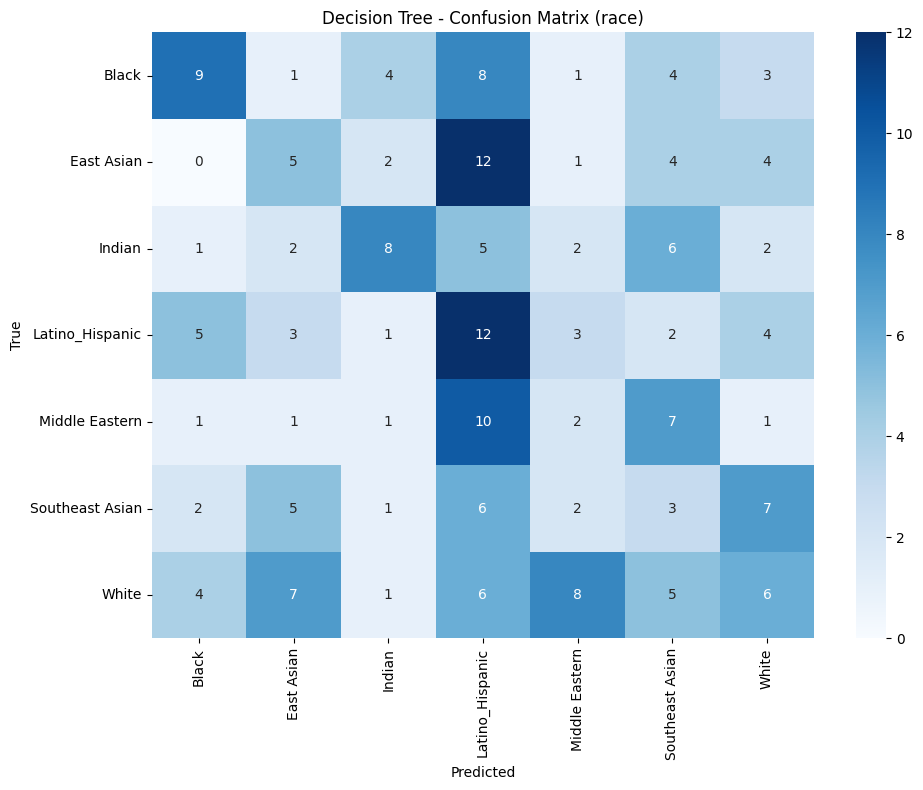

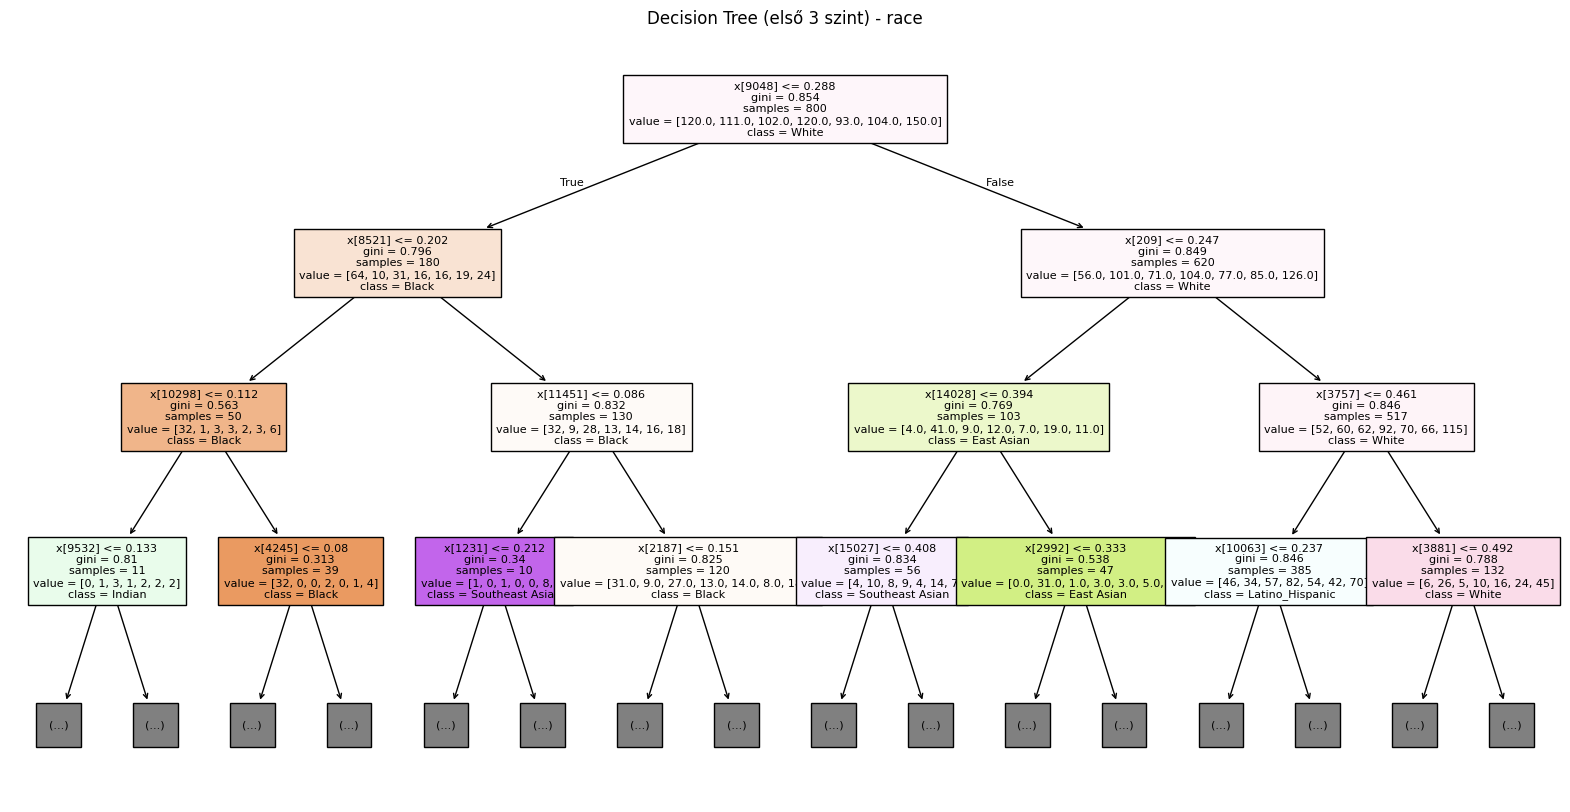


Random Forest - race
Accuracy: 0.335
Weighted F1: 0.3037957893783213

Classification report:

                 precision    recall  f1-score   support

          Black       0.36      0.53      0.43        30
     East Asian       0.48      0.50      0.49        28
         Indian       0.18      0.12      0.14        26
Latino_Hispanic       0.26      0.17      0.20        30
 Middle Eastern       0.50      0.09      0.15        23
Southeast Asian       0.67      0.15      0.25        26
          White       0.29      0.62      0.39        37

       accuracy                           0.34       200
      macro avg       0.39      0.31      0.29       200
   weighted avg       0.38      0.34      0.30       200



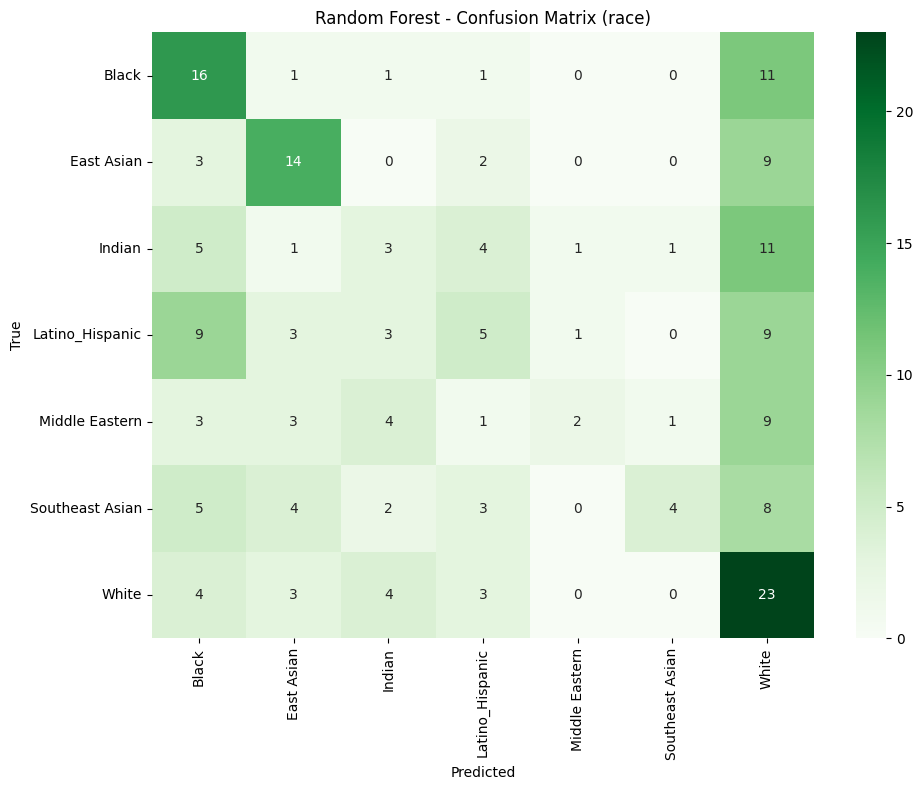

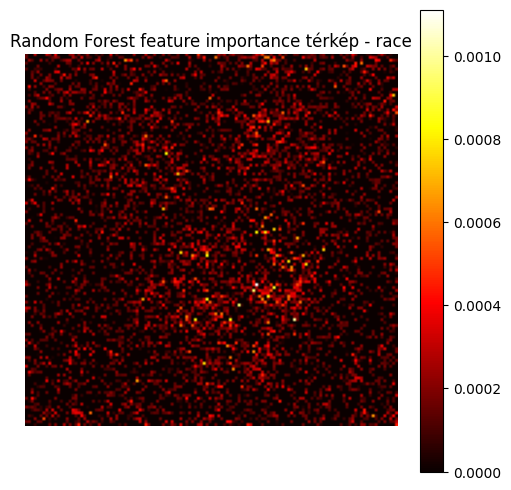


TARGET: GENDER

Szűrés utáni eloszlás:
gender
Male      540
Female    460
Name: count, dtype: int64

Osztályok: ['Female', 'Male']
Kódolt címke példa: [1 1 0 1 1 1 1 1 0 1]
Train: (800, 16384) (800,)
Test: (200, 16384) (200,)

Decision Tree - gender
Accuracy: 0.55
Weighted F1: 0.5503165511003919

Classification report:

              precision    recall  f1-score   support

      Female       0.51      0.52      0.52        92
        Male       0.58      0.57      0.58       108

    accuracy                           0.55       200
   macro avg       0.55      0.55      0.55       200
weighted avg       0.55      0.55      0.55       200



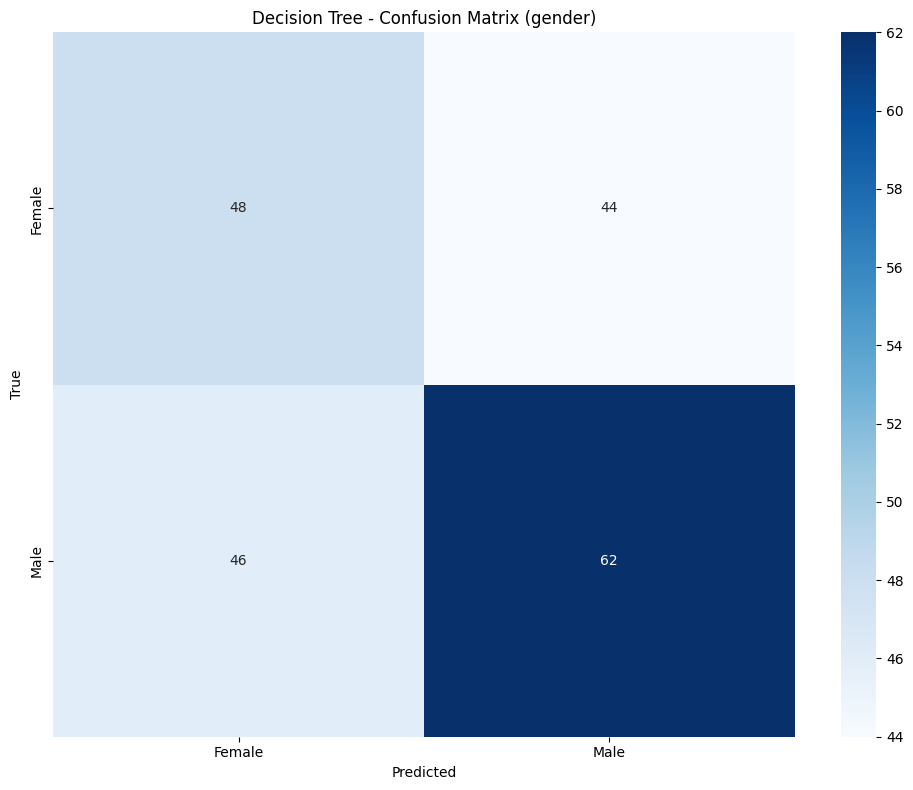

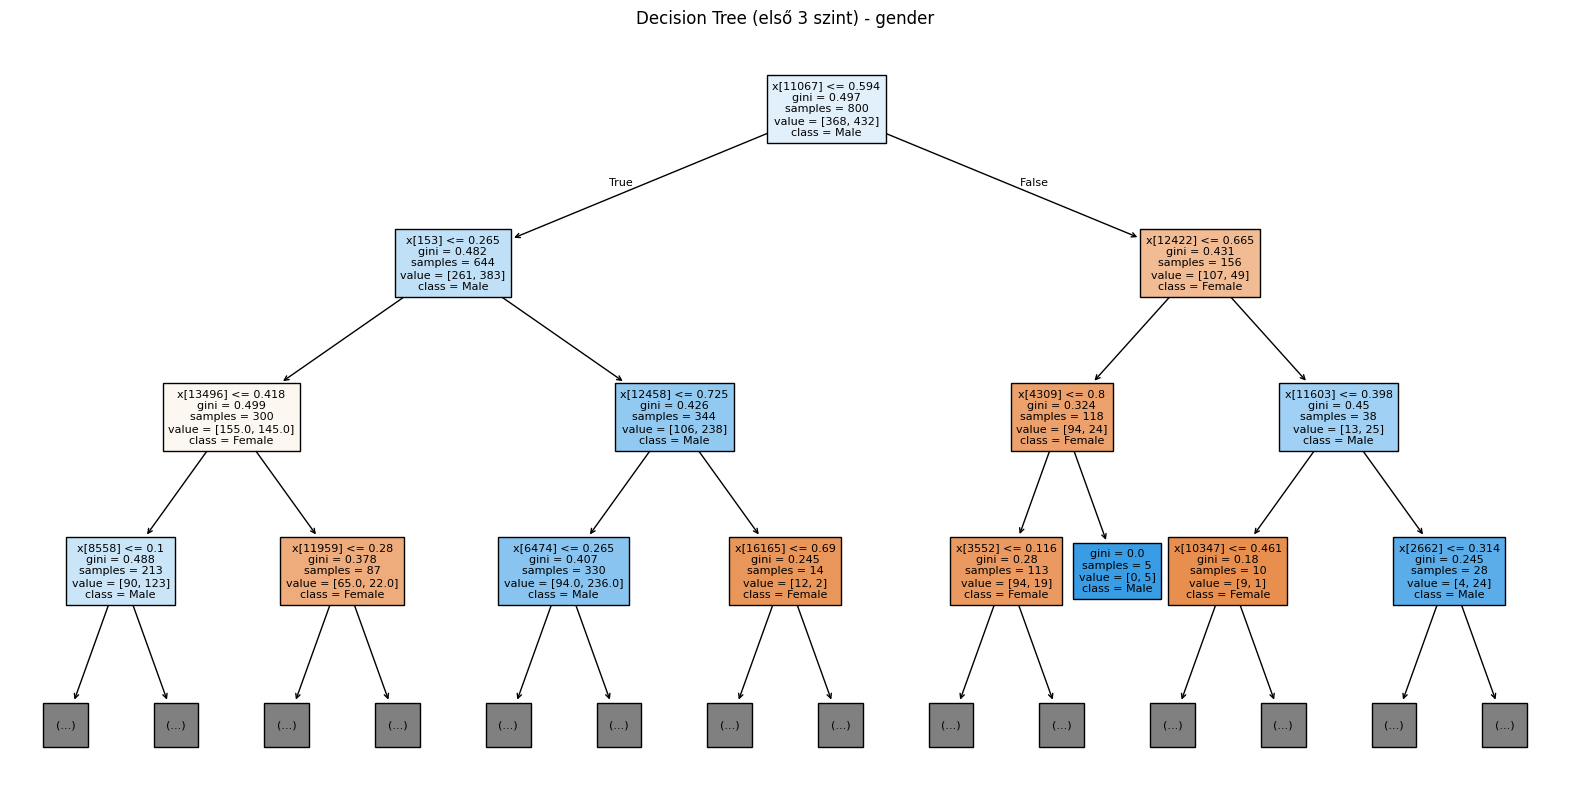


Random Forest - gender
Accuracy: 0.635
Weighted F1: 0.6238924274593064

Classification report:

              precision    recall  f1-score   support

      Female       0.65      0.46      0.54        92
        Male       0.63      0.79      0.70       108

    accuracy                           0.64       200
   macro avg       0.64      0.62      0.62       200
weighted avg       0.64      0.64      0.62       200



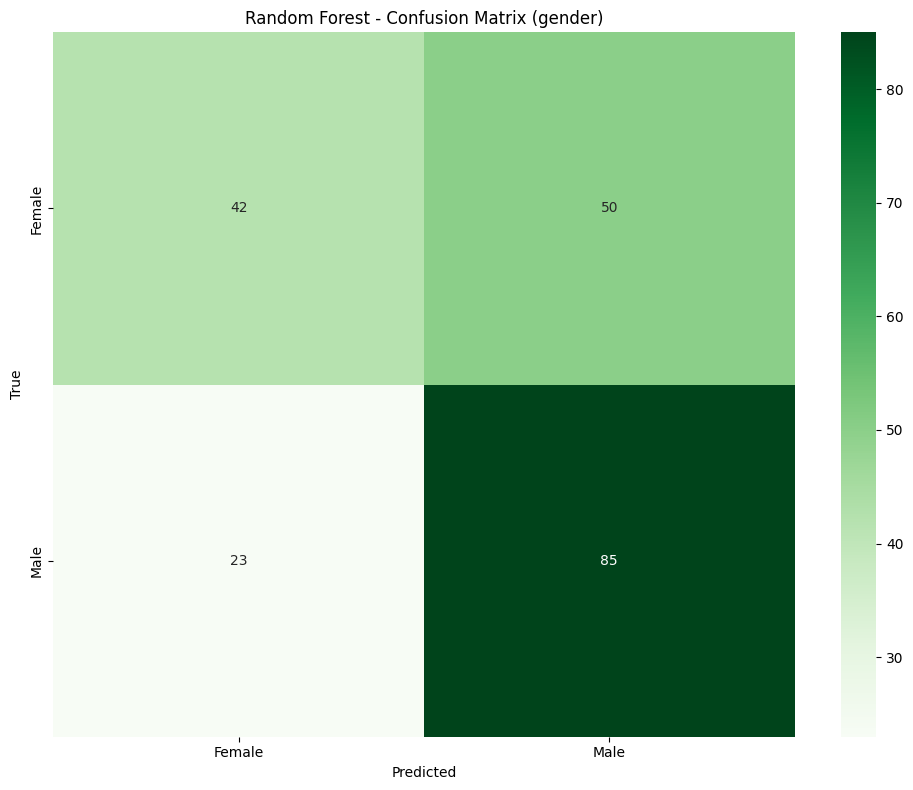

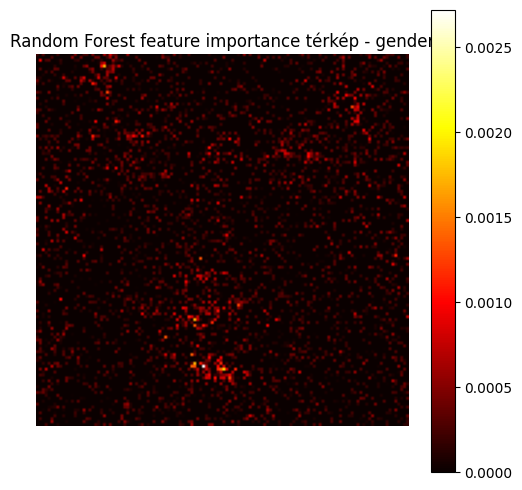


TARGET: AGE

Osztályarányok:
age
20-29           0.292
30-39           0.227
3-9             0.123
40-49           0.116
10-19           0.114
50-59           0.068
60-69           0.034
0-2             0.017
more than 70    0.009
Name: proportion, dtype: float64

Szűrés: min_class_ratio = 0.05
Megtartott osztályok: ['20-29', '30-39', '3-9', '40-49', '10-19', '50-59']

Szűrés utáni eloszlás:
age
20-29    292
30-39    227
3-9      123
40-49    116
10-19    114
50-59     68
Name: count, dtype: int64

Osztályok: ['10-19', '20-29', '3-9', '30-39', '40-49', '50-59']
Kódolt címke példa: [1 3 0 3 0 1 2 5 1 0]
Train: (752, 16384) (752,)
Test: (188, 16384) (188,)

Decision Tree - age
Accuracy: 0.19148936170212766
Weighted F1: 0.19136904793592224

Classification report:

              precision    recall  f1-score   support

       10-19       0.07      0.09      0.08        23
       20-29       0.25      0.28      0.26        58
         3-9       0.25      0.16      0.20        25
       30-

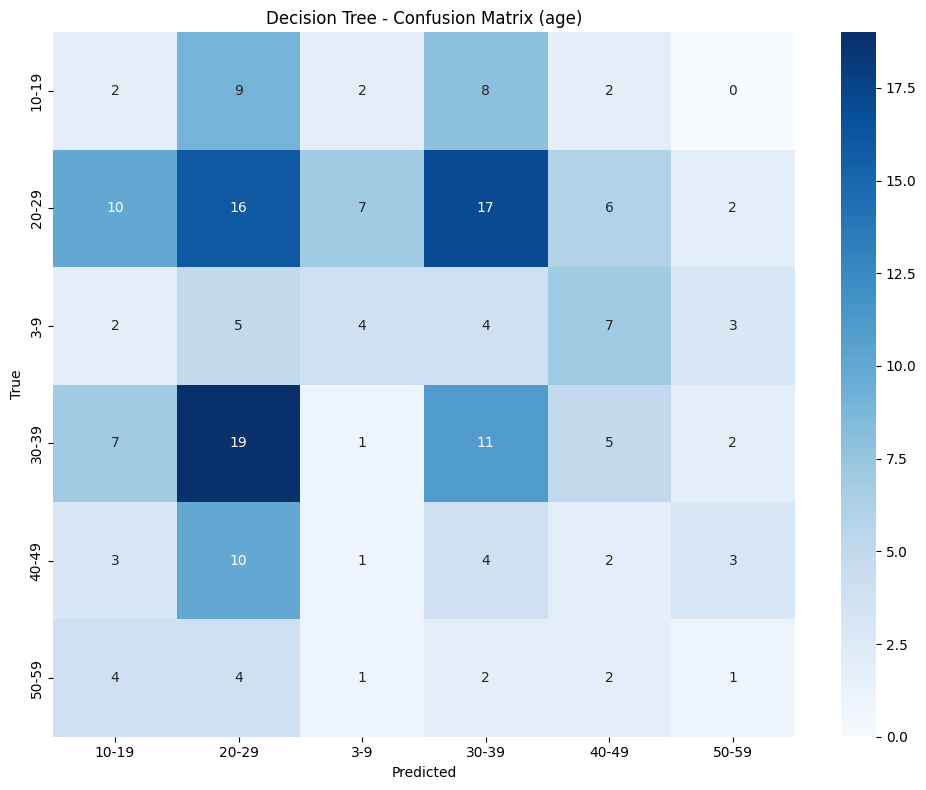

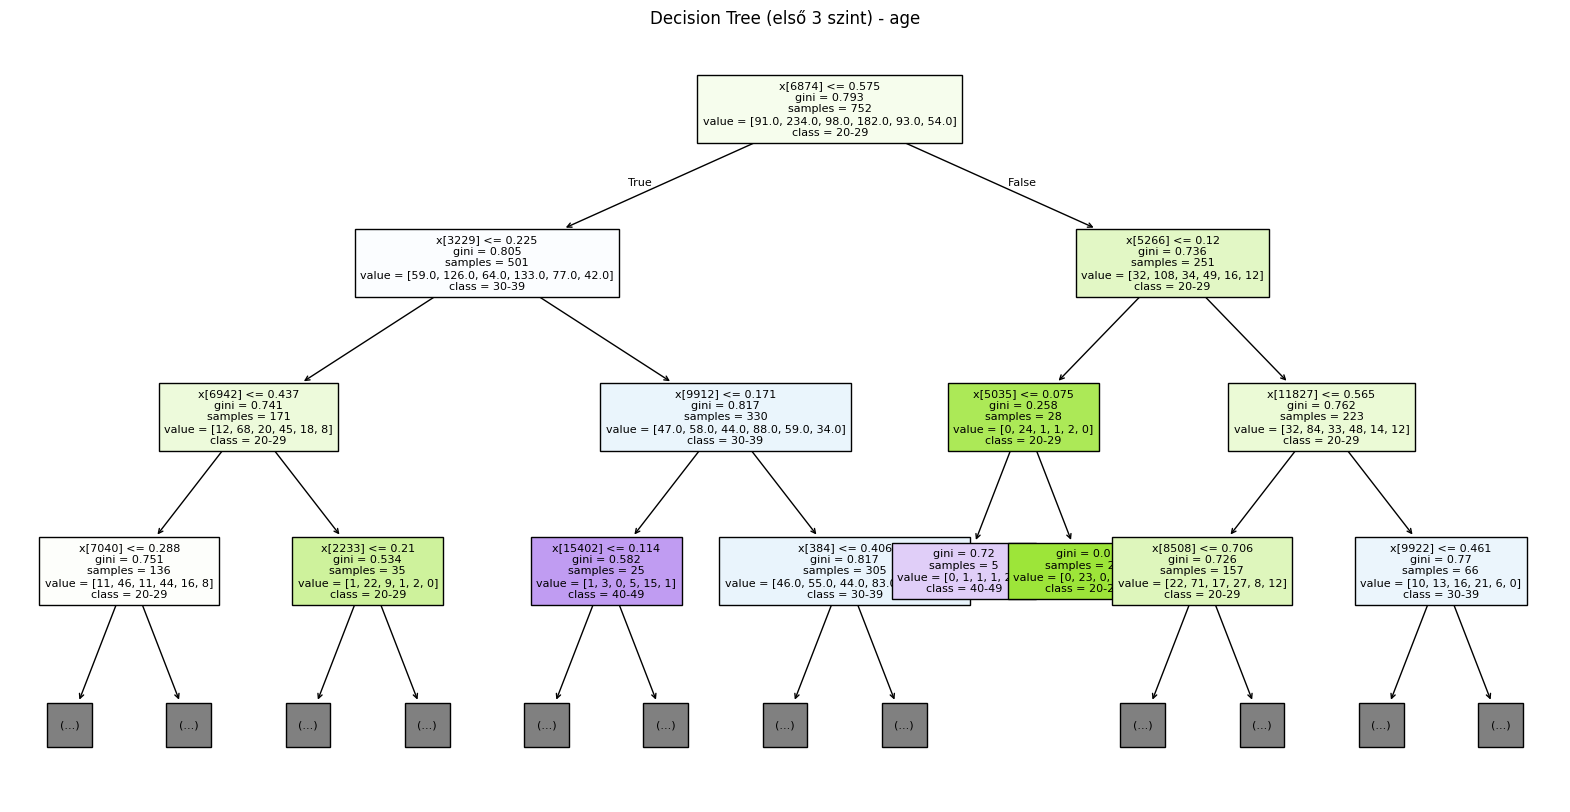


Random Forest - age
Accuracy: 0.28191489361702127
Weighted F1: 0.21762034562375634

Classification report:

              precision    recall  f1-score   support

       10-19       0.50      0.04      0.08        23
       20-29       0.30      0.62      0.41        58
         3-9       1.00      0.08      0.15        25
       30-39       0.23      0.31      0.26        45
       40-49       0.00      0.00      0.00        23
       50-59       0.00      0.00      0.00        14

    accuracy                           0.28       188
   macro avg       0.34      0.18      0.15       188
weighted avg       0.34      0.28      0.22       188



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


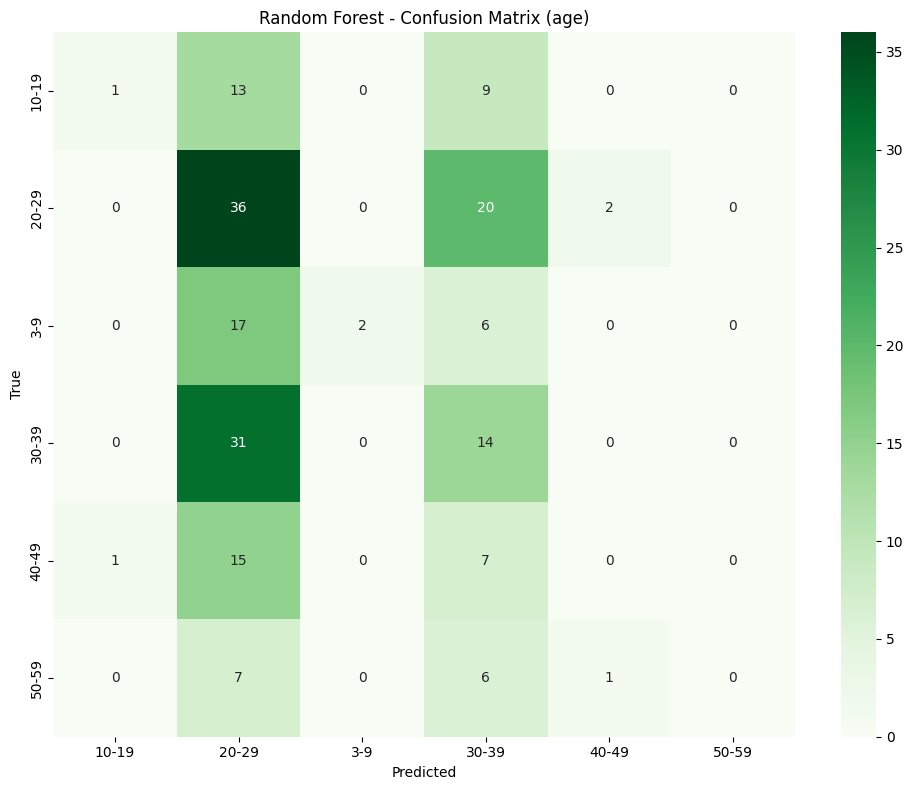

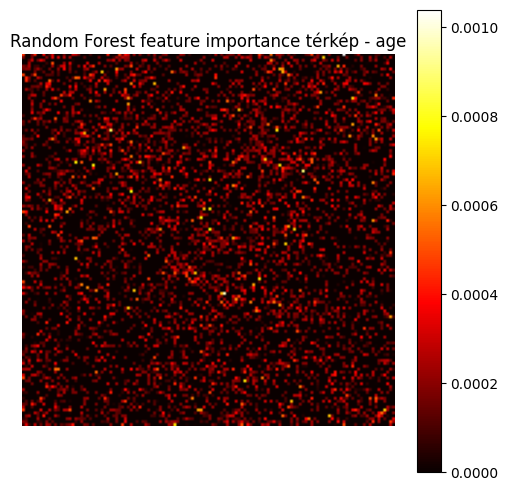

In [94]:
results = {}

results["race"] = train_and_evaluate_for_target(X, meta_df, "race")

results["gender"] = train_and_evaluate_for_target(X, meta_df, "gender")

results["age"] = train_and_evaluate_for_target(
    X,
    meta_df,
    "age",
    min_class_ratio=0.05
)

In [95]:
summary = []
for target, res in results.items():
    summary.append({
        "target": target,
        "dt_accuracy": res["dt_accuracy"],
        "dt_f1": res["dt_f1"],
        "rf_accuracy": res["rf_accuracy"],
        "rf_f1": res["rf_f1"],
    })

summary_df = pd.DataFrame(summary)
display(summary_df)

,target,dt_accuracy,dt_f1,rf_accuracy,rf_f1
0,race,0.225000,0.225892,0.335000,0.303796
1,gender,0.550000,0.550317,0.635000,0.623892
2,age,0.191489,0.191369,0.281915,0.217620
